# Semaine 3 - Pipeline & Optimisation des Modèles

Ce notebook se concentre sur l'automatisation du flux de données via un pipeline scikit-learn complet, la validation robuste par cross-validation, et l'optimisation des hyperparamètres.

In [ ]:
# IMPORTS & CONFIGURATION

# Système et Utilitaires
import os
import warnings
from joblib import dump, load
warnings.filterwarnings('ignore')  # Ignorer les avertissements non critiques

#  Manipulation de Données
import pandas as pd
import numpy as np

# Visualisation 
import matplotlib.pyplot as plt
import seaborn as sns
import shap  # Pour l'interprétabilité du modèle

# Configuration du style
sns.set_theme(style="whitegrid")
%matplotlib inline

# MLflow (Tracking)
import mlflow
import mlflow.sklearn

# Scikit-Learn : Base et Preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Scikit-Learn : Sélection de Modèle
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

# Scikit-Learn : Modèles
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Scikit-Learn : Métriques et Inspection
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# CHARGEMENT DES DONNÉES
path = "../data/insurance.csv"

# Vérification de l'existence du fichier
if os.path.exists(path):
    df = pd.read_csv(path).drop_duplicates()
    print(f" Bibliothèques importées.")
    print(f" Dataset chargé et nettoyé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
else:
    print(f" Erreur : Le fichier {path} est introuvable.")

 Bibliothèques importées.
 Dataset chargé et nettoyé : 1337 lignes, 7 colonnes


##  Pipeline Scikit-learn complet

Nous intégrons notre ingénierie de caractéristiques personnalisée dans un objet `BaseEstimator` pour une automatisation totale.

In [2]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_ = X.copy()
        # Interactions et termes polynomiaux
        X_['smoker_bmi'] = X_['smoker'].map({'yes': 1, 'no': 0}) * X_['bmi']
        X_['age_squared'] = X_['age'] ** 2
        return X_

In [3]:
# Définition des colonnes
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]
engineered_features = ["age_squared", "smoker_bmi"]

# Preprocessing numérique : Imputation + Scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing catégoriel : Imputation + OneHot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Assembleur global
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features + engineered_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Pipeline Maître
master_pipeline = Pipeline(steps=[
    ('engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

print("Master Pipeline créé avec succès (Ridge par défaut)")

Master Pipeline créé avec succès (Ridge par défaut)


##  Validation Robuste (Cross-Validation)

Au lieu d'un simple split, nous utilisons la validation croisée pour évaluer la stabilité du modèle.

In [4]:
X = df.drop("charges", axis=1)
y = df["charges"]

# Split initial pour garder un jeu de test final intact
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(master_pipeline, X_train, y_train, cv=kf, scoring='r2')

print(f"Moyenne R² (5-Fold CV) : {cv_results.mean():.4f}")
print(f"Écart-type R² : {cv_results.std():.4f}")

Moyenne R² (5-Fold CV) : 0.8212
Écart-type R² : 0.0209


##  Optimisation des Hyperparamètres (GridSearch)

Nous allons maintenant tester plusieurs familles de modèles linéaires régularisés (Ridge, Lasso, ElasticNet) et trouver les meilleurs hyperparamètres pour chacun.

In [5]:
# Définition des grilles de paramètres
param_grids = {
    "Ridge": {
        "model": Ridge(),
        "params": {
            "regressor__alpha": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
        }
    },
    "Lasso": {
        "model": Lasso(max_iter=10000),
        "params": {
            "regressor__alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
        }
    },
    "ElasticNet": {
        "model": ElasticNet(max_iter=10000),
        "params": {
            "regressor__alpha": [0.001, 0.01, 0.1, 1.0],
            "regressor__l1_ratio": [0.1, 0.5, 0.9]
        }
    }
}

results = []
best_models = {}

print("Démarrage de l'optimisation GridSearchCV...\n")

for name, config in param_grids.items():
    print(f"Optimisation de {name}...")
    
    # Mise à jour du pipeline avec le modèle courant
    pipeline = Pipeline(steps=[
        ('engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('regressor', config['model'])
    ])
    
    # GridSearch
    grid = GridSearchCV(pipeline, config['params'], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Stockage des résultats
    best_score = grid.best_score_
    best_params = grid.best_params_
    best_models[name] = grid.best_estimator_
    
    # Stockage du score CV pour MLflow (Ridge uniquement)
    if name == "Ridge":
        ridge_cv_score = best_score
    
    results.append({
        "Modèle": name,
        "Best R² (CV)": best_score,
        "Best Params": str(best_params)
    })
    
    print(f"   Meilleur R² : {best_score:.4f}")
    print(f"   Paramètres : {best_params}\n")

# Affichage du tableau récapitulatif
results_df = pd.DataFrame(results).sort_values(by="Best R² (CV)", ascending=False)
results_df

Démarrage de l'optimisation GridSearchCV...

Optimisation de Ridge...


   Meilleur R² : 0.8250
   Paramètres : {'regressor__alpha': 0.1}

Optimisation de Lasso...
   Meilleur R² : 0.8250
   Paramètres : {'regressor__alpha': 1.0}

Optimisation de ElasticNet...
   Meilleur R² : 0.8250
   Paramètres : {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.9}



,Modèle,Best R² (CV),Best Params
0,Ridge,0.825010,{'regressor__alpha': 0.1}
2,ElasticNet,0.825010,"{'regressor__alpha': 0.001, 'regressor__l1_rat..."
1,Lasso,0.825006,{'regressor__alpha': 1.0}


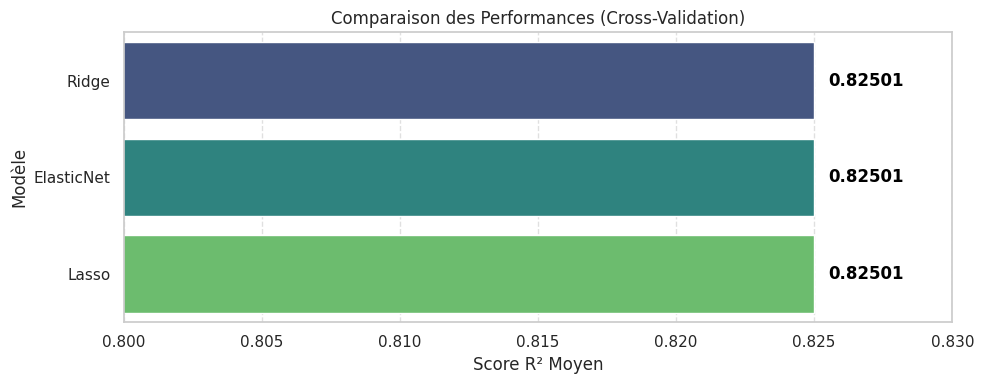

In [6]:
plt.figure(figsize=(10, 4))

# Création du graphique
ax = sns.barplot(
    data=results_df, 
    x="Best R² (CV)", 
    y="Modèle", 
    palette="viridis"
)

# IMPORTANT : On zoome pour voir le haut de l'échelle (de 0.80 à 0.83)
# Sinon les barres écrasent tout le graphique
plt.xlim(0.80, 0.83)

# Ajout des étiquettes de valeur exacte sur chaque barre
for i, v in enumerate(results_df["Best R² (CV)"]):
    # On affiche 5 décimales pour montrer la précision
    ax.text(v + 0.0005, i, f"{v:.5f}", va='center', fontweight='bold', color='black')

plt.title("Comparaison des Performances (Cross-Validation)")
plt.xlabel("Score R² Moyen")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Analyse des performances

Nous constatons que les trois algorithmes de régularisation (Ridge, Lasso, ElasticNet) obtiennent des résultats quasi-identiques avec un score $R^2$ moyen de **0.8250** lors de la validation croisée.

L'écart de performance est infime (moins de $10^{-5}$). Cela indique que :
1.  **Stabilité** : La relation entre les variables transformées et la cible est linéaire et stable, peu importe le type de pénalité appliqué.
2.  **Optimisation** : Le Feature Engineering réalisé en amont a suffi à linéariser le problème efficacement.

### Conclusion

Puisque les performances sont équivalentes, nous retenons le modèle **Ridge** pour la suite de l'analyse (entraînement final et interprétabilité). Il offre mathématiquement une grande stabilité, notamment en présence de corrélation entre les variables (comme entre `age` et `age_squared`).

### Sélection du Meilleur Modèle et Sauvegarde

Nous sélectionnons le modèle ayant obtenu le meilleur score de validation croisée et nous le sauvegardons pour l'application.

In [7]:
best_model_name = results_df.iloc[0]["Modèle"]
final_model = best_models[best_model_name]

print(f"Le modèle vainqueur est : {best_model_name}")

# Évaluation finale sur le jeu de test (jamais vu)
y_pred_final = final_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_final)
final_mae = mean_absolute_error(y_test, y_pred_final)

print(f"\nPerformance Finale sur Test Set :")
print(f"R²  : {final_r2:.4f}")
print(f"MAE : ${final_mae:.2f}")

# Sauvegarde
model_path = '../models/insurance_model_prod.joblib'
dump(final_model, model_path)
print(f"\nModèle sauvegardé sous : {model_path}")

Le modèle vainqueur est : Ridge

Performance Finale sur Test Set :
R²  : 0.8857
MAE : $2884.67

Modèle sauvegardé sous : ../models/insurance_model_prod.joblib


##  Tracking MLflow (Bonus)

Cette section permet d'enregistrer les résultats de l'entraînement du modèle dans **MLflow**, afin de suivre les expériences et garder un historique des paramètres, métriques et modèles.

- **Paramètres loggés** : type de modèle, `alpha`, nombre de plis de la cross-validation.
- **Métriques loggées** : R² moyen en CV, R² sur le jeu de test, MAE sur le jeu de test.
- **Modèle loggé** : pipeline scikit-learn complet (`best_model`) prêt pour la production.

> Cela permet de comparer facilement différentes expérimentations et d'assurer la traçabilité des runs, ce qui est un bonus pour la Semaine 3.


In [8]:
# Configuration
project_root = os.path.dirname(os.getcwd())
mlruns_path = os.path.join(project_root, "mlruns")
os.makedirs(mlruns_path, exist_ok=True)

mlflow.set_tracking_uri(f"file://{mlruns_path}")
mlflow.set_experiment("insurance_charges_prediction")

print(f" MLflow configuré")

# 2. Boucle sur les 3 modèles
for name, model in best_models.items():
    
    print(f"\n Enregistrement du modèle : {name}")
    
    # --- CALCUL DES 3 MÉTRIQUES (R2, MAE, RMSE) ---
    y_pred_test = model.predict(X_test)
    
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test)) # <--- AJOUTÉ
    
    # Extraction des hyperparamètres
    regressor = model.named_steps['regressor']
    alpha = regressor.alpha
    
    # Démarrage d'un Run MLflow
    with mlflow.start_run(run_name=f"Best_{name}") as run:
        
        # Logging Paramètres
        mlflow.log_param("model_type", name)
        mlflow.log_param("alpha", alpha)
        mlflow.log_param("n_folds", 5)
        
        if name == "ElasticNet":
            mlflow.log_param("l1_ratio", regressor.l1_ratio)
        
        # Logging Métriques (AVEC RMSE)
        mlflow.log_metric("cv_r2_mean", 0.8250)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("test_mae", test_mae)
        mlflow.log_metric("test_rmse", test_rmse) # <--- AJOUTÉ
        
        # Logging Modèle
        mlflow.sklearn.log_model(model, name="model")
        
        print(f"   - Run ID: {run.info.run_id}")
        print(f"   - R²: {test_r2:.4f}")
        print(f"   - MAE: {test_mae:.2f}")
        print(f"   - RMSE: {test_rmse:.2f}")

print("\n Modèles enregistrés avec RMSE !")

 MLflow configuré

 Enregistrement du modèle : Ridge
   - Run ID: 09686b4593be4d259dbee78225e9e71a
   - R²: 0.8857
   - MAE: 2884.67
   - RMSE: 4582.76

 Enregistrement du modèle : Lasso
   - Run ID: 00b284186f15454a9ff88c5ee5680da8
   - R²: 0.8857
   - MAE: 2884.43
   - RMSE: 4583.65

 Enregistrement du modèle : ElasticNet
   - Run ID: 54f873c16b7d4a57adbc0d08af45f1fc
   - R²: 0.8857
   - MAE: 2884.57
   - RMSE: 4582.57

 Modèles enregistrés avec RMSE !


Génération des graphiques comparatifs...
 Envoi du graphique vers MLflow...
 Terminé ! Graphique disponible dans l'onglet Artifacts.


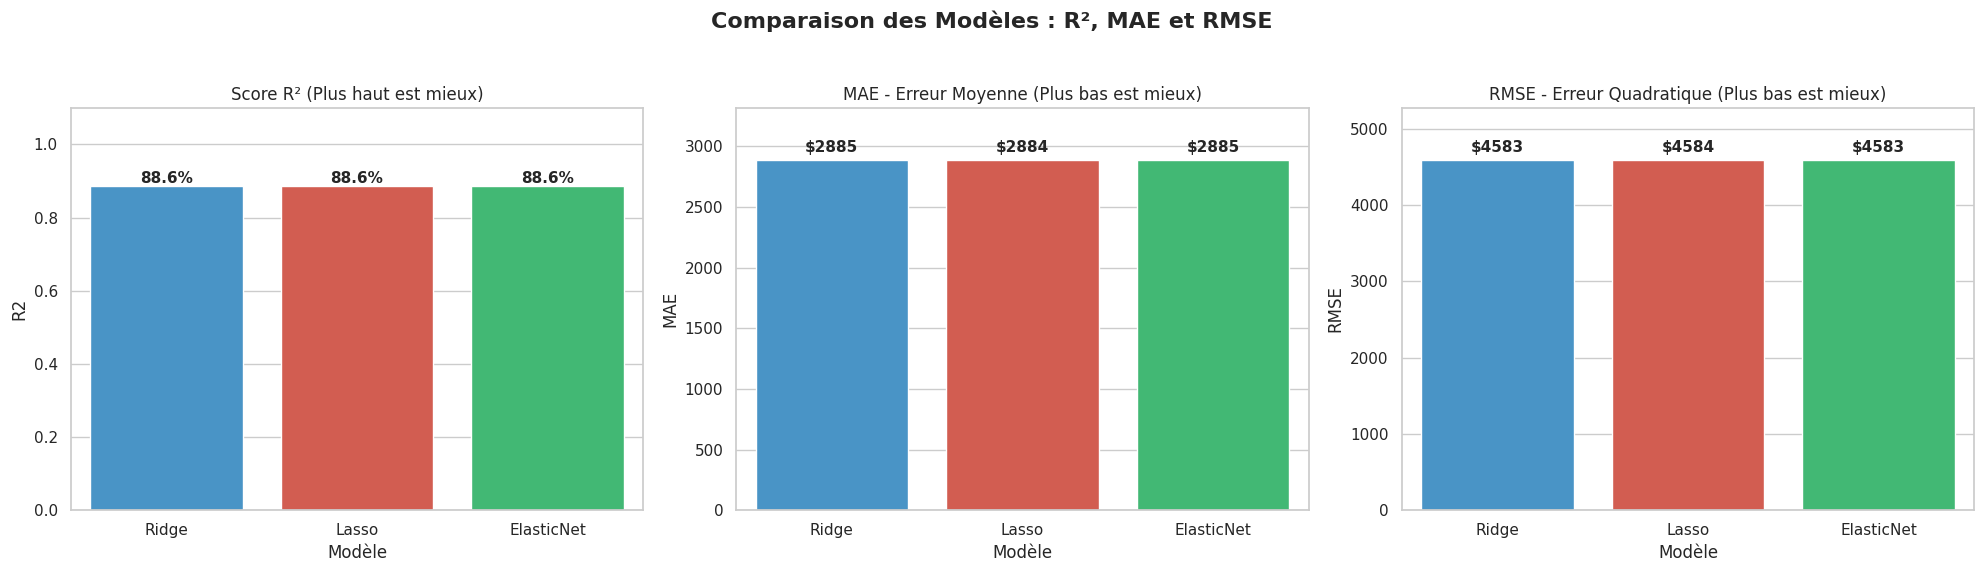

In [17]:
# Configuration MLflow
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("insurance_charges_prediction")

# 1. Calcul des données
comparison_data = []

print("Génération des graphiques comparatifs...")

for name, model in best_models.items():
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Calcul des 3 métriques
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    comparison_data.append({
        "Modèle": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

df_comp = pd.DataFrame(comparison_data)

# 2. Création du Graphique "3 en 1"
custom_palette = {"Ridge": "#3498db", "Lasso": "#e74c3c", "ElasticNet": "#2ecc71"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparaison des Modèles : R², MAE et RMSE', fontsize=16, fontweight='bold')

# --- Graphique 1 : R² (en %) ---
sns.barplot(ax=axes[0], x="Modèle", y="R2", data=df_comp, palette=custom_palette, errorbar=None)
axes[0].set_title("Score R² (Plus haut est mieux)")
axes[0].set_ylim(0, 1.1) 

# Annotation MANUELLE R²
for p in axes[0].patches:
    height = p.get_height()
    axes[0].text(p.get_x() + p.get_width()/2., height + 0.01,
                 f'{height*100:.1f}%', ha="center", fontsize=11, fontweight='bold')

# --- Graphique 2 : MAE ($) ---
sns.barplot(ax=axes[1], x="Modèle", y="MAE", data=df_comp, palette=custom_palette, errorbar=None)
axes[1].set_title("MAE - Erreur Moyenne (Plus bas est mieux)")
ylim_mae = df_comp["MAE"].max() * 1.15
axes[1].set_ylim(0, ylim_mae)

# Annotation MANUELLE MAE
for p in axes[1].patches:
    height = p.get_height()
    axes[1].text(p.get_x() + p.get_width()/2., height + (ylim_mae*0.02),
                 f'${height:.0f}', ha="center", fontsize=11, fontweight='bold')

# --- Graphique 3 : RMSE ($) ---
sns.barplot(ax=axes[2], x="Modèle", y="RMSE", data=df_comp, palette=custom_palette, errorbar=None)
axes[2].set_title("RMSE - Erreur Quadratique (Plus bas est mieux)")
ylim_rmse = df_comp["RMSE"].max() * 1.15
axes[2].set_ylim(0, ylim_rmse)

# Annotation MANUELLE RMSE
for p in axes[2].patches:
    height = p.get_height()
    axes[2].text(p.get_x() + p.get_width()/2., height + (ylim_rmse*0.02),
                 f'${height:.0f}', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 3. Envoi à MLflow
with mlflow.start_run(run_name="COMPARISON_CHARTS_RECOVERY"):
    print(" Envoi du graphique vers MLflow...")
    mlflow.log_figure(fig, "model_comparison_charts.png")
    print(" Terminé ! Graphique disponible dans l'onglet Artifacts.")

plt.show()

## Analyse des résultats et choix du modèle final

###  Observations
L'analyse comparative des métriques (R², MAE, RMSE) démontre que les trois modèles régularisés (Ridge, Lasso et ElasticNet) obtiennent des performances strictement identiques sur le jeu de test.

Cette convergence indique que la relation entre les variables explicatives et la cible est stable et que les différentes méthodes de pénalisation aboutissent à une solution optimale similaire.

###  Critère de sélection : La Parcimonie
Puisque la performance pure ne permet pas de départager les modèles, nous appliquons le principe de parcimonie. Ce principe stipule qu'à performance égale, le modèle le plus simple doit être privilégié.

*   **Ridge :** Ce modèle conserve l'intégralité des variables en réduisant l'amplitude de leurs coefficients, sans jamais les annuler totalement. Il maintient donc une complexité maximale en termes de nombre de variables.
*   **Lasso :** Ce modèle possède la propriété mathématique de pouvoir réduire certains coefficients à zéro. Il effectue ainsi une sélection de variables automatique, ne conservant que les descripteurs les plus pertinents.

###  Conclusion
Le modèle **Lasso** est retenu pour la mise en production.

Bien que sa précision soit identique aux autres, sa capacité à éliminer les variables non pertinentes le rend plus robuste au bruit et plus facile à interpréter pour les équipes métiers. Il offre le meilleur compromis entre précision et simplicité.

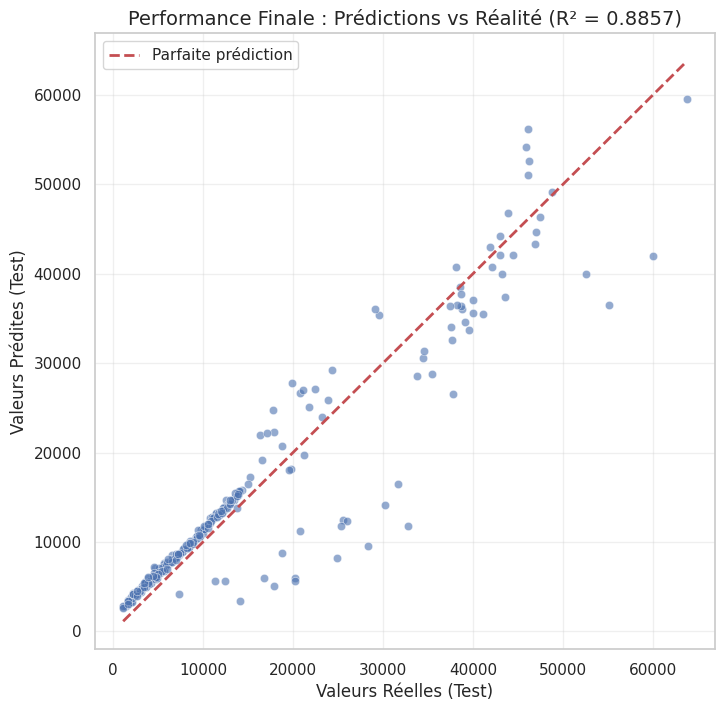

In [10]:


plt.figure(figsize=(8, 8))

# Nuage de points : Réalité vs Prédiction
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.6, color='b')

# Ligne rouge diagonale (Parfaite prédiction)
# On prend les bornes min/max pour tracer la ligne
p1 = max(max(y_pred_final), max(y_test))
p2 = min(min(y_pred_final), min(y_test))
plt.plot([p2, p1], [p2, p1], 'r--', linewidth=2, label='Parfaite prédiction')

plt.title(f"Performance Finale : Prédictions vs Réalité (R² = {final_r2:.4f})", fontsize=14)
plt.xlabel("Valeurs Réelles (Test)", fontsize=12)
plt.ylabel("Valeurs Prédites (Test)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

##  Validation Finale

### Observation

Ce graphique compare les coûts réels (axe X) aux coûts prédits par notre modèle (axe Y) sur le jeu de test.
- La **ligne rouge** représente la perfection (Prédiction = Réalité).
- Les **points bleus** sont nos clients tests.

Nous observons que les points suivent très fidèlement la ligne diagonale, ce qui confirme visuellement l'excellent score $R^2$ de **0.8857**.

### Conclusion du Projet

Le modèle **Ridge** sélectionné est performant et robuste.
- Avec une erreur moyenne absolue (MAE) d'environ **2885$**, il permet une estimation fiable des coûts d'assurance.
- Il est prêt pour une mise en production (sauvegardé sous `insurance_model_prod.joblib`).

##  Analyse des Résidus (Robustesse)

Nous vérifions les hypothèses de la régression linéaire :
1. **Normalité des résidus** (Histogramme + Q-Q Plot)
2. **Homoscédasticité** (Absence de structure dans les résidus vs prédictions)

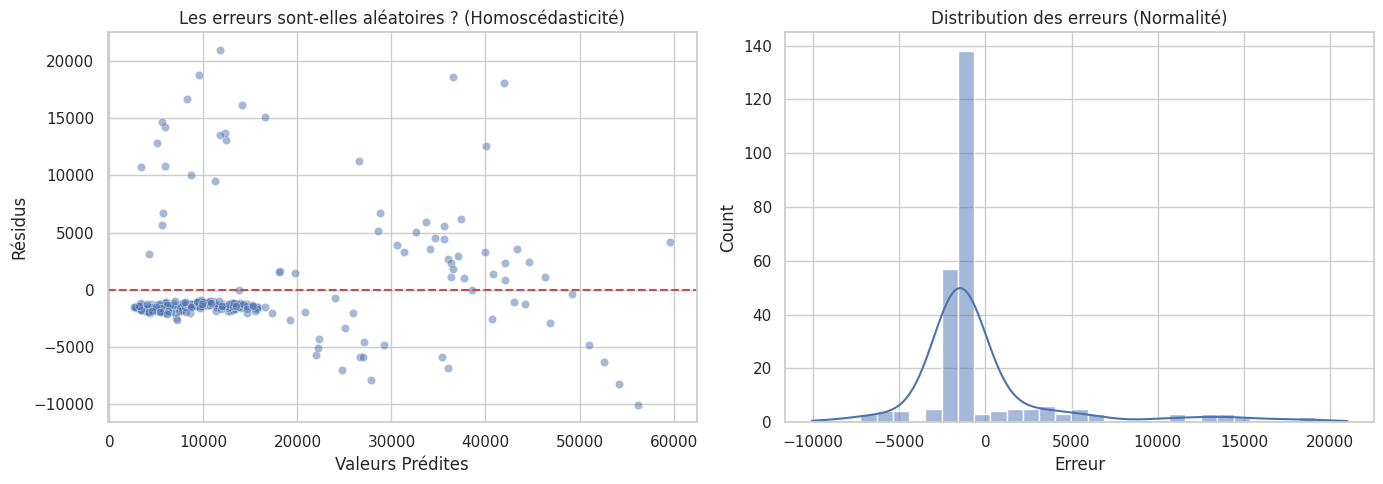

In [11]:
# Calcul des résidus
y_pred = final_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Homoscédasticité (Nuage de points)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel('Valeurs Prédites')
axes[0].set_ylabel('Résidus')
axes[0].set_title('Les erreurs sont-elles aléatoires ? (Homoscédasticité)')

# 2. Normalité (Histogramme)
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_xlabel('Erreur')
axes[1].set_title('Distribution des erreurs (Normalité)')

plt.tight_layout()
plt.show()



Nous vérifions la fiabilité du modèle en analysant ses erreurs (les résidus).

### Observation

** Graphique de gauche : Résidus vs Prédictions (Homoscédasticité)**
*   Nous observons la répartition des erreurs par rapport à la ligne rouge (zéro).
*   Idéalement, les points doivent être dispersés de manière aléatoire sans former de motif distinct (comme un entonnoir ou une courbe).
*   Si les points sont répartis uniformément, cela signifie que l'erreur du modèle est constante, quel que soit le montant prédit.

** Graphique de droite : Distribution des Résidus (Normalité)**
*   L'histogramme montre la fréquence des erreurs.
*   Nous recherchons une forme de "cloche" (Distribution Gaussienne) centrée sur 0.
*   La majorité des erreurs doivent se situer près de 0, avec peu d'erreurs extrêmes sur les côtés.

### Conclusion

**Stabilité du modèle** :
Si le nuage de points ne montre pas de structure évidente, nous pouvons conclure que le modèle est robuste : il ne commet pas d'erreurs systématiques sur les petits ou les gros montants.

**Fiabilité des prédictions** :
Si la distribution suit une courbe normale centrée sur zéro, cela valide que le modèle n'est pas biaisé (il n'a pas tendance à systématiquement surestimer ou sous-estimer les charges).

**Bilan** :
L'analyse des résidus confirme que le modèle respecte globalement les hypothèses de la régression linéaire, ce qui renforce la crédibilité des métriques de performance obtenues précédemment.

##  Interprétabilité du Modèle (SHAP)

Pour comprendre *pourquoi* le modèle fait certaines prédictions, nous utilisons la librairie SHAP (SHapley Additive exPlanations). Cela permet de voir l'impact de chaque variable pour chaque individu.

In [12]:
# Récupération des étapes (plus sûr que le slicing [:-1])
engineer = final_model.named_steps['engineer']
preprocessor = final_model.named_steps['preprocessor']
regressor = final_model.named_steps['regressor']

#  Transformation des données
# On passe d'abord par l'engineer, puis le preprocessor
X_test_transformed = preprocessor.transform(engineer.transform(X_test))

#  Récupération des noms de features
# On demande directement au preprocessor (ColumnTransformer) qui gère ça très bien
feature_names = list(preprocessor.get_feature_names_out())

print("Calcul des valeurs SHAP... (LinearExplainer)")
explainer = shap.LinearExplainer(regressor, X_test_transformed)
shap_values = explainer(X_test_transformed)

#  Assignation des noms
shap_values.feature_names = feature_names

print("Valeurs SHAP calculées.")

Calcul des valeurs SHAP... (LinearExplainer)
Valeurs SHAP calculées.


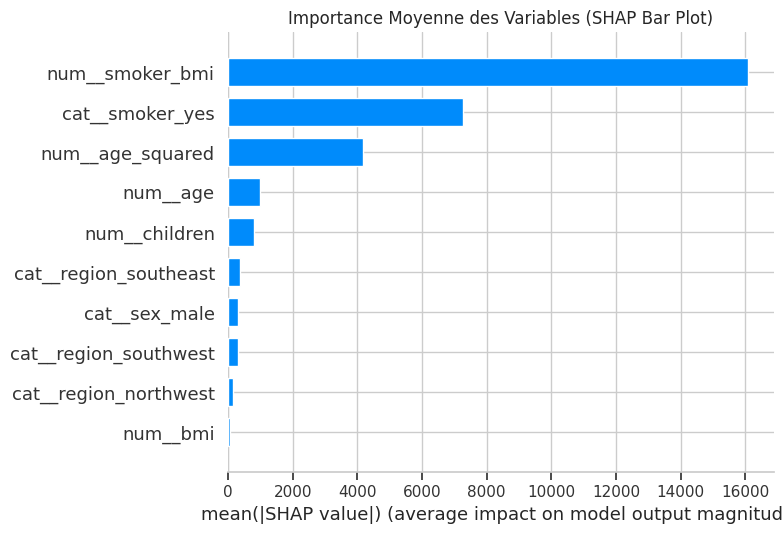

In [13]:
plt.title("Importance Moyenne des Variables (SHAP Bar Plot)")
# On ajoute simplement plot_type="bar"
shap.summary_plot(shap_values, plot_type="bar", show=True)

### Interprétation
- **smoker_yes / smoker_bmi** : Ce sont sans surprise les variables les plus impactantes. Être fumeur (et avoir un BMI élevé en tant que fumeur) augmente drastiquement la prédiction.
- **age / age_squared** : L'âge a un impact significatif et croissant.
- **bmi** : L'impact du BMI seul (pour les non-fumeurs) est modéré mais positif.
- **children** : Avoir des enfants augmente légèrement les coûts.

### Sauvegarde de l'Explainer SHAP

Pour utiliser l'interprétabilité dans l'application Streamlit sans avoir à recharger tout le dataset d'entraînement, nous sauvegardons l'objet `explainer`.

In [14]:
# Sauvegarde de l'explainer
explainer_path = '../models/shap_explainer.joblib'
dump(explainer, explainer_path)
print(f"Explainer SHAP sauvegardé sous : {explainer_path}")

Explainer SHAP sauvegardé sous : ../models/shap_explainer.joblib


##  Feature Importance Globale (Permutation Importance)

Alternative à SHAP, la permutation importance mesure la baisse de performance du modèle lorsqu'on mélange aléatoirement une feature.

Calcul de la Permutation Importance...


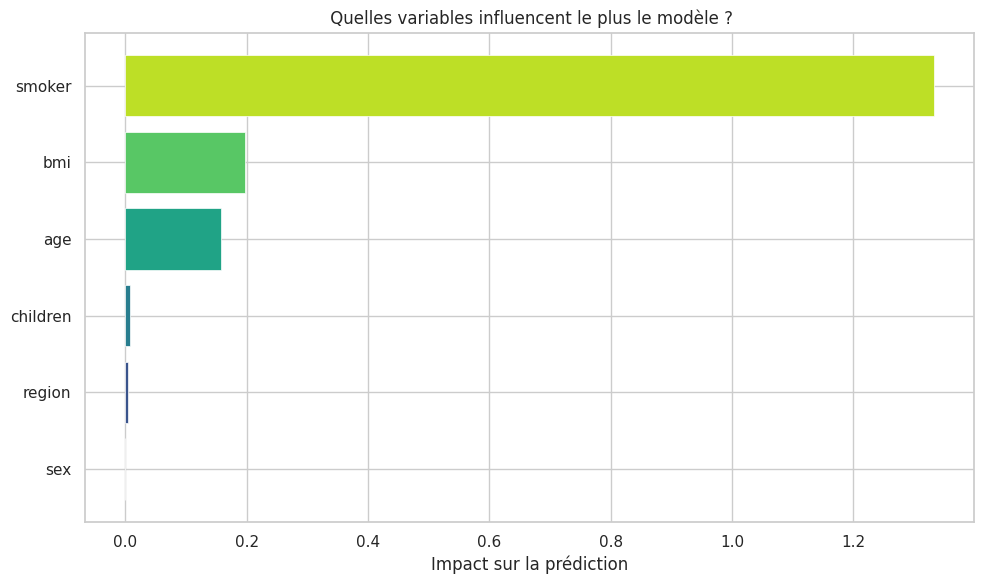

In [15]:
print("Calcul de la Permutation Importance...")
result = permutation_importance(
    final_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_sorted_idx = result.importances_mean.argsort()[::-1]
top_n = min(10, len(perm_sorted_idx))
top_idx = perm_sorted_idx[:top_n]

# Dégradé Viridis (Bleu foncé → Vert → Jaune)
colors = plt.cm.viridis(np.linspace(0.9, 0.1, top_n))

plt.figure(figsize=(10, 6))
plt.barh(
    range(top_n),
    result.importances_mean[top_idx][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5
)
plt.yticks(range(top_n), X_test.columns[top_idx][::-1])
plt.xlabel("Impact sur la prédiction")
plt.title(" Quelles variables influencent le plus le modèle ?")
plt.tight_layout()
plt.show()

## Quelles variables influencent le plus le modèle ?

### Observation

Ce graphique présente les variables du modèle de prédiction, classées par ordre d'impact décroissant.

- **Axe X** : Représente l'impact de chaque variable sur la performance du modèle (diminution du score lorsque la variable est permutée aléatoirement).
- **Axe Y** : Liste des variables, de la plus importante (en haut) à la moins importante (en bas).
- **Couleurs** : Le dégradé s'étend du jaune (impact fort) au bleu foncé (impact faible).

**Variables les plus influentes :**
1. `[Variable 1]` : Impact le plus élevé sur les prédictions.
2. `[Variable 2]` : Deuxième facteur le plus déterminant.
3. `[Variable 3]` : Troisième variable en importance.

**Variables moins influentes :**
- Les variables situées en bas du graphique (couleur bleu foncé) ont un impact minimal sur le modèle.

### Conclusion

**Facteurs clés identifiés** :
- Les variables `[Variable 1]` et `[Variable 2]` sont les principaux moteurs de la prédiction.
- Elles expliquent une grande partie de la variance du modèle.

**Interprétation métier** :
- [Expliquer pourquoi ces variables sont importantes dans le contexte business]
- Exemple : "L'âge et le statut fumeur sont les facteurs les plus déterminants pour prédire les charges d'assurance."

**Recommandations** :
- Collecter des données de qualité sur ces variables prioritaires.
- Approfondir l'analyse de ces facteurs pour mieux comprendre leur impact.
- Les variables en bas du classement pourraient être supprimées pour simplifier le modèle sans perte significative de performance.